<a href="https://colab.research.google.com/github/loicPf/test_ia/blob/main/02_mpg_qualite_pertinence_structur%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapitre 2 — Évaluer la qualité et la pertinence des données (Exemple : Dataset MPG)

## Objectif
Mesurer la **qualité** des données et évaluer leur **pertinence** par rapport à l’objectif métier.

### Contexte (MPG)
- **Cible** : `mpg` (consommation, *miles per gallon*)
- **Question métier** : *Quelle est la consommation d’une voiture en fonction de ses caractéristiques ?*



## 0) Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)
sns.set_theme()


## 1) Charger le dataset MPG

In [ ]:
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## 2) Définir la cible et les variables explicatives

In [ ]:
target = 'mpg'
features = [c for c in df.columns if c != target]
print('Cible :', target)
print('Variables explicatives :', features)
df.columns

Cible : mpg
Variables explicatives : ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name'], dtype='object')

## 3) Profil rapide : dimensions, types, aperçu

In [ ]:
print('Shape :', df.shape)
df.info()

Shape : (398, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


## 4) Les indicateurs clés de qualité (rappel)
- **Complétude** : % de valeurs manquantes
- **Cohérence** : valeurs logiquement possibles (ex: poids > 0)
- **Exactitude** : concordance avec la réalité (souvent difficile sans source externe)
- **Pertinence** : utile pour l’objectif et disponible au moment de la prédiction


## 5) Complétude : valeurs manquantes

In [ ]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)
quality_missing = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
quality_missing.head(10)


,missing_count,missing_pct
horsepower,6,1.51
mpg,0,0.00
cylinders,0,0.00
displacement,0,0.00
weight,0,0.00
acceleration,0,0.00
model_year,0,0.00
origin,0,0.00
name,0,0.00


## 6) Doublons exacts

In [ ]:
n_duplicates = df.duplicated().sum()
print('Doublons exacts :', n_duplicates)

Doublons exacts : 0


## 7) Cohérence : règles simples (valeurs impossibles)

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
summary = df[numeric_cols].describe().T[['min', 'max', 'mean', 'std']]
summary

,min,max,mean,std
mpg,9.0,46.6,23.514573,7.815984
cylinders,3.0,8.0,5.454774,1.701004
displacement,68.0,455.0,193.425879,104.269838
horsepower,46.0,230.0,104.469388,38.491160
weight,1613.0,5140.0,2970.424623,846.841774
acceleration,8.0,24.8,15.568090,2.757689
model_year,70.0,82.0,76.010050,3.697627


### 7.1) Détecter des valeurs non-positives (si cela a du sens)

In [ ]:
checks = {}
for col in numeric_cols:
    if col in df.columns:
        checks[col] = (df[col] <= 0).sum()
pd.Series(checks, name='nb_valeurs_<=0')

,nb_valeurs_<=0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0


## 8) Évaluation visuelle (repérer anomalies & distributions)
On utilise : **histogrammes**, **boxplots**, **scatter plots**, **heatmap de corrélation**.

### 8.1) Histogramme de `mpg`

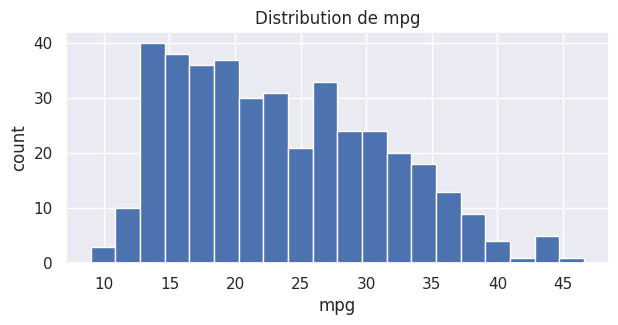

In [ ]:
plt.figure(figsize=(7,3))
plt.hist(df['mpg'].dropna(), bins=20)
plt.title('Distribution de mpg')
plt.xlabel('mpg')
plt.ylabel('count')
plt.show()

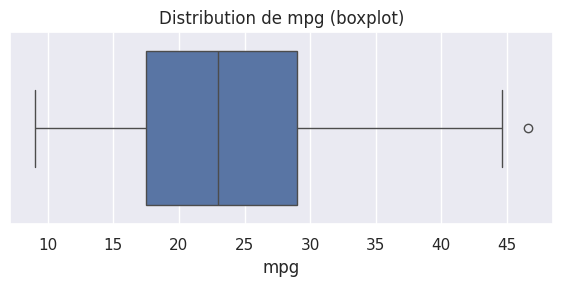

In [ ]:
plt.figure(figsize=(7,2.5))
sns.boxplot(x=df['mpg'])
plt.title('Distribution de mpg (boxplot)')
plt.xlabel('mpg')
plt.show()

### 8.2) Boxplot de `weight` (détecter valeurs extrêmes)

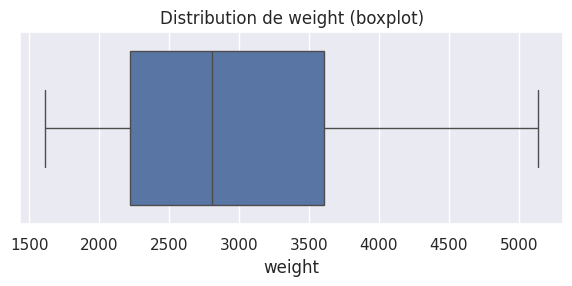

In [ ]:
plt.figure(figsize=(7,2.5))
sns.boxplot(x=df['weight'])
plt.title('Distribution de weight (boxplot)')
plt.xlabel('weight')
plt.show()

In [ ]:
f = df["mpg"].dropna()

q1 = f.quantile(0.25)
q3 = f.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outliers_fare = int(((f < lower) | (f > upper)).sum())

print("Q1 =", round(q1, 2), "| Q3 =", round(q3, 2), "| IQR =", round(iqr, 2))
print("lower =", round(lower, 2), "| upper =", round(upper, 2))
print("n_outliers_fare =", n_outliers_fare)

Q1 = 17.5 | Q3 = 29.0 | IQR = 11.5
lower = 0.25 | upper = 46.25
n_outliers_fare = 1


### 8.3) Scatter plot : `mpg` vs `weight`

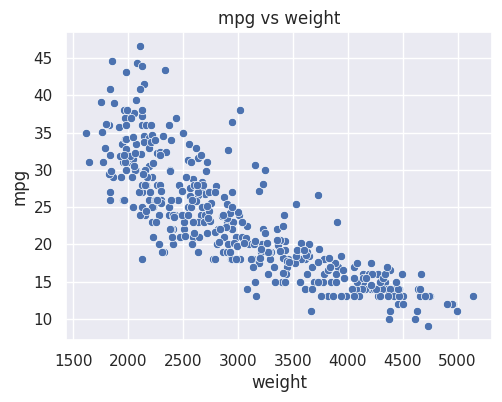

In [ ]:
plt.figure(figsize=(5.5,4))
sns.scatterplot(data=df, x='weight', y='mpg')
plt.title('mpg vs weight')
plt.show()

### 8.4) Heatmap de corrélation (variables numériques)

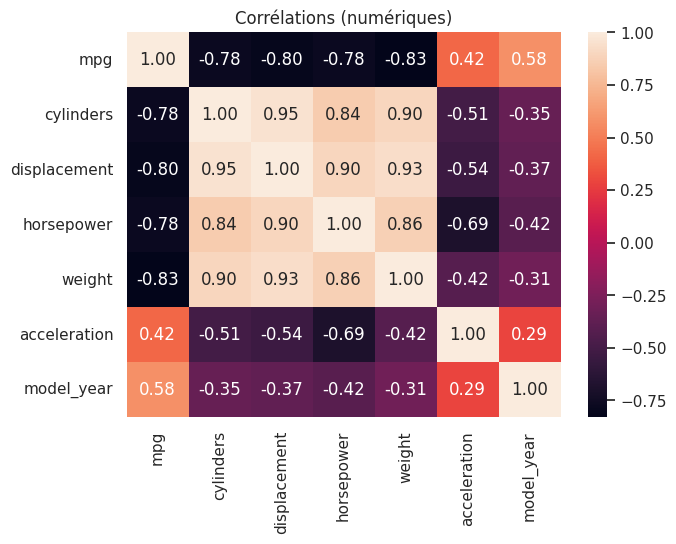

In [ ]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Corrélations (numériques)')
plt.show()

## 9) Évaluer la pertinence (lié à l’objectif)
Questions simples :
1) Cette variable influence-t-elle la cible ?
2) Est-elle disponible au moment où je dois prédire ?
3) Est-elle exploitable techniquement ?
4) Est-elle acceptable légalement/éthiquement (PII) ?


### 9.1) Signal rapide : corrélation avec `mpg` (numériques)

In [ ]:
corr_with_target = corr['mpg']
corr_with_target

,mpg
mpg,1.000000
cylinders,-0.775396
displacement,-0.804203
horsepower,-0.778427
weight,-0.831741
acceleration,0.420289
model_year,0.579267


### 9.2) Effet d’une variable catégorielle : `origin`

In [ ]:
df.groupby('origin')['mpg'].mean().sort_values(ascending=False).round(2)

,mpg
origin,
japan,30.45
europe,27.89
usa,20.08


### 9.3) Variable `name` : souvent peu pertinente pour un modèle simple

In [ ]:
df['name'].head(5)

,name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino


## 10) Exemple de décisions qualité (simple)

### 10.1) Gérer les valeurs manquantes (ex : `horsepower`)

In [ ]:
df['horsepower'].isna().sum()

np.int64(6)

In [ ]:
df_clean = df.dropna(subset=['horsepower']).copy()
print('Avant:', df.shape, '| Après:', df_clean.shape)

Avant: (398, 9) | Après: (392, 9)


### 10.2) Enlever une colonne peu pertinente (optionnel)

In [ ]:
df_model = df_clean.drop(columns=['name'])
df_model.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


## 12) QCM — Évaluer la qualité et la pertinence (10 questions)

https://docs.google.com/forms/d/e/1FAIpQLSf5OPj6aHcdAOyI6LnPq9lH-YZTU_-_wXjuxx-seyS759LSHg/viewform?usp=publish-editor